## pypacity

### CIGRE TB 601 (2014): Transient conductor temperature

#### (PAG 84)


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

from cigre601 import cigre601
from cable import cable
from case import case
from utils import pvsystems
from datetime import datetime

import matplotlib.pyplot as plt 
import numpy as np

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [2]:
# Thermal equilibrium before calculating the transient temperature

Cable = cable.Cable()
c_db, error = Cable.load_cable_db()
Cable.set_cable(1, conductor = 'DRAKE')

Cable.ABSORP = 0.8
Cable.EMISS  = 0.8

NSELECT = 1

Case_ss = case.Case()
Case_ss.demo( NSELECT )

Case_ss.CDR_LAT_DEG = 30
Case_ss.CDR_ELEV = 0
Case_ss.ALBEDO = 0.1
Case_ss.beta   = 0
Case_ss.Z1_DEG = 0

Case_ss.SOLAR = 0
Case_ss.SolarRadiation = 0

Case_ss.XIPRELOAD = 802
Case_ss.DWIND_DEG = 55
Case_ss.TAMB  = 24
Case_ss.VWIND = 1.9

TB601 = cigre601.CIGRE601()
TB601.Debug = 0
TB601.set_cable( Cable )
TB601.set_case(  Case_ss  )
TB601.cigre601()
TB601.output()

Tc0 = Case_ss.TCDRPRELOAD

 
 
*******************************************************************
*******************************************************************
CIGRE TB601 
*******************************************************************
+The angle between wind and conductor is =  55  DEG
INPUT -> Steady-state current:  802  A
OUTPUT -> Steady-state temperature:  42.017  ºC
Solar heating:   0.0  W/m
Radiation cooling:  8.273  W/m
Convection cooling:  41.607  W/m
Temperature difference between conductor surface and core: 3.883 ºC


In [3]:
# Transient temperature calculation
NSELECT = 3

DWIND_DEG = np.array([62,37])
XISTEP = np.array([819,856])
TAMB   = np.array([23.7,23.5])
VWIND  = np.array([1.7,0.8])

Tc = []

# loop for two steps
for ti in range(2):

    Case_tr = case.Case()
    Case_tr.demo( NSELECT )

    Case_tr.TTfromST  = 0     
    if len(Tc)==0: Case_tr.TCDRinitial = Tc0
    else:          Case_tr.TCDRinitial = Tc[-1]

    Case_tr.CDR_LAT_DEG = 30
    Case_tr.CDR_ELEV = 0
    Case_tr.ALBEDO = 0.1
    Case_tr.beta   = 0
    Case_tr.Z1_DEG = 0

    Case_tr.SolarRadiation = 0
    Case_tr.SOLAR = 0

    Case_tr.DWIND_DEG = DWIND_DEG[ti]
    Case_tr.VWIND     = VWIND[ti]
    Case_tr.TAMB      = TAMB[ti]

    Case_tr.SORM    = 1
    Case_tr.TT      = 10 
    Case_tr.DELTIME = 60

    Case_tr.XISTEP = XISTEP[ti]

    TB601 = cigre601.CIGRE601()
    TB601.Debug = 0
    TB601.set_cable( Cable )
    TB601.set_case(  Case_tr )
    TB601.cigre601()

    if ti==0: Tc.extend(TB601.Case1.ATCDR)
    else:     Tc.extend(TB601.Case1.ATCDR[1:])


steps:  10
Tinitial: 42.017°C  dT:0.165
Tinitial: 42.182°C  dT:0.146
Tinitial: 42.328°C  dT:0.129
Tinitial: 42.457°C  dT:0.114
Tinitial: 42.570°C  dT:0.100
Tinitial: 42.670°C  dT:0.088
Tinitial: 42.759°C  dT:0.078
Tinitial: 42.836°C  dT:0.069
Tinitial: 42.905°C  dT:0.061
Tinitial: 42.966°C  dT:0.053
steps:  10
Tinitial: 43.019°C  dT:1.136
Tinitial: 44.155°C  dT:1.051
Tinitial: 45.206°C  dT:0.973
Tinitial: 46.179°C  dT:0.900
Tinitial: 47.080°C  dT:0.833
Tinitial: 47.913°C  dT:0.771
Tinitial: 48.684°C  dT:0.713
Tinitial: 49.396°C  dT:0.659
Tinitial: 50.055°C  dT:0.609
Tinitial: 50.665°C  dT:0.563


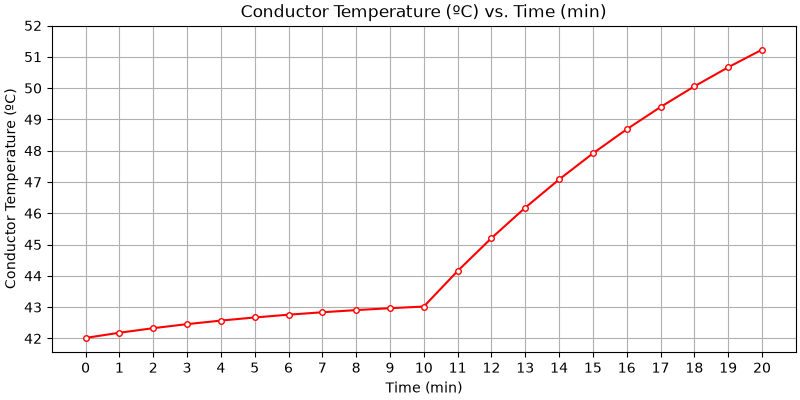

In [4]:
fig, ax  = plt.subplots(1,1,constrained_layout=True,figsize=(8,4))

ax.plot(Tc,'ro-',ms=4,mfc='w')
ax.set_title("Conductor Temperature (ºC) vs. Time (min)")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Conductor Temperature (ºC)")
ax.set_xticks(np.arange(0,21))
ax.set_yticks(np.arange(42,53))
ax.grid();